# Airbnb Price Prediction - Exploratory Data Analysis

## Objective

The goal of this notebook is to understand the Airbnb dataset before any preprocessing or feature engineering.

During this notebook we will:

- Understand the structure of the dataset
- Explore data types
- Identify missing values
- Investigate the target variable
- Explore numerical and categorical features
- Detect potential data quality issues
- Identify opportunities for feature engineering

> **Note:** No modifications to the dataset will be performed in this notebook. Cleaning and preprocessing will be completed in Notebook 02.

# 1. Imports

In [55]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
plt.style.use("ggplot")

# 2. Load the dataset

In [56]:
df = pd.read_csv("../data/raw/Airbnb_Data.csv")
df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


# 3. Basic Information

In [57]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 74111
Columns: 29


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  str    
 3   room_type               74111 non-null  str    
 4   amenities               74111 non-null  str    
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  str    
 8   cancellation_policy     74111 non-null  str    
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  str    
 11  description             74111 non-null  str    
 12  first_review            58247 non-null  str    
 13  host_has_profile_pic    73923 non-null  str    
 14  host_identity_verified  73923 non-null  str    
 

In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,74111.0,1.126662e+07,6.081735e+06,344.000000,6.261964e+06,1.225415e+07,1.640226e+07,2.123090e+07
log_price,74111.0,4.782069e+00,7.173938e-01,0.000000,4.317488e+00,4.709530e+00,5.220356e+00,7.600402e+00
accommodates,74111.0,3.155146e+00,2.153589e+00,1.000000,2.000000e+00,2.000000e+00,4.000000e+00,1.600000e+01
bathrooms,73911.0,1.235263e+00,5.820441e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e+00
latitude,74111.0,3.844596e+01,3.080167e+00,33.338905,3.412791e+01,4.066214e+01,4.074610e+01,4.239044e+01
longitude,74111.0,-9.239753e+01,2.170532e+01,-122.511500,-1.183424e+02,-7.699696e+01,-7.395466e+01,-7.098505e+01
number_of_reviews,74111.0,2.090057e+01,3.782864e+01,0.000000,1.000000e+00,6.000000e+00,2.300000e+01,6.050000e+02
review_scores_rating,57389.0,9.406736e+01,7.836556e+00,20.000000,9.200000e+01,9.600000e+01,1.000000e+02,1.000000e+02
bedrooms,74020.0,1.265793e+00,8.521435e-01,0.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
beds,73980.0,1.710868e+00,1.254142e+00,0.000000,1.000000e+00,1.000000e+00,2.000000e+00,1.800000e+01


In [60]:
df.describe(include="object").T

,count,unique,top,freq
property_type,74111,35,Apartment,49003
room_type,74111,3,Entire home/apt,41310
amenities,74111,67122,{},586
bed_type,74111,5,Real Bed,72028
cancellation_policy,74111,5,strict,32374
city,74111,6,NYC,32349
description,74111,73479,"Hello, I've been running guest house for Korea...",8
first_review,58247,2554,2017-01-01,293
host_has_profile_pic,73923,2,t,73697
host_identity_verified,73923,2,t,49748


# 4. Missing Values

What are the problems?

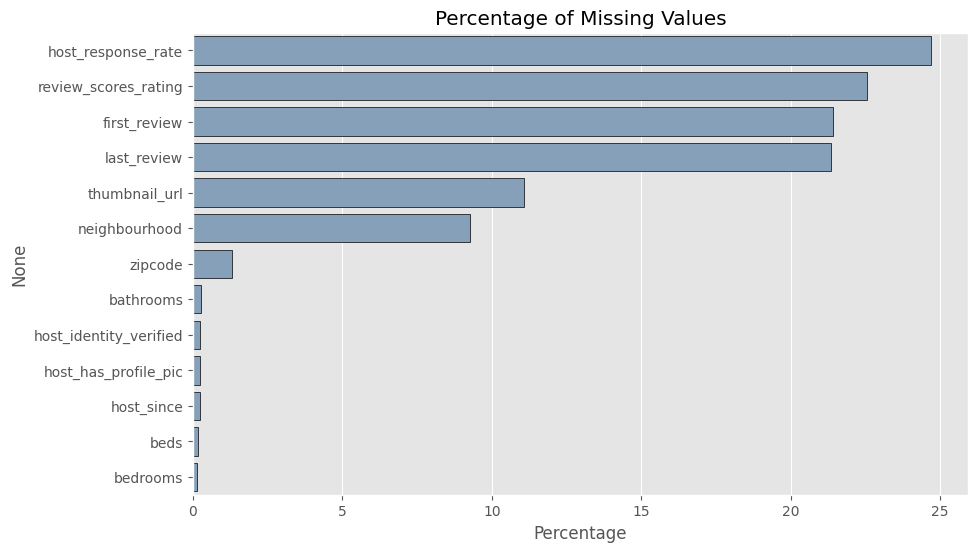

In [61]:
missing = (df.isnull().sum().sort_values(ascending=False).to_frame("Missing Values"))
missing["Percentage"] = (missing["Missing Values"] / len(df)) * 100

missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(10, 6))
sns.barplot(x="Percentage", y=missing.index, data=missing, color="#7ca1c0", edgecolor="black")
plt.title("Percentage of Missing Values")
plt.show()

# 5. Duplicate Rows

In [62]:
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


# 6. Target Variable

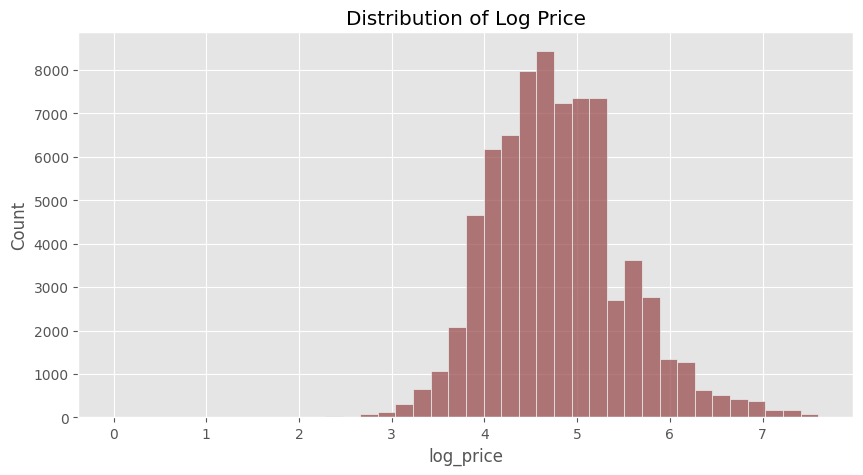

In [63]:
plt.figure(figsize=(10, 5))
sns.histplot(df["log_price"], bins=40, color="#9a4f50")
plt.title("Distribution of Log Price")
plt.show()

# 7. Data Types

In [64]:
df.dtypes.value_counts()

str        18
float64     7
int64       3
bool        1
Name: count, dtype: int64

### Observations

- The dataset contains four primary data types (int64, float64, bool, and object). Several features currently stored as strings (e.g., dates and percentages) will require conversion during preprocessing.

- Duplicate handling in the cleaning process won't be a problem as there are no duplicates.

- Listing price is roughly normally distributed though it has a few observations in the tails of the distribution, suggesting some low and high listing prices.

- `host_response_rate`, `review_scores_rating`, `first_review`, `last_review` have the highest number of missing values, above 20%.

- `first_review`, `last_review` and `host_since` are stored as strings instead of datetime objects.

- `host_response_rate` contains percentage strings (%) and will require parsing before numerical analysis.

- The `amenities` column has extremely high cardinality because each listing contains a unique combination of amenities. Rather than encoding the raw strings, this feature will require custom parsing and feature engineering.

# 8. Numerical Feature Analysis

Identify numerical features

In [65]:
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.to_list()

# remove the target and id
numerical_features.remove("id")
numerical_features.remove("log_price")

numerical_features

['accommodates',
 'bathrooms',
 'latitude',
 'longitude',
 'number_of_reviews',
 'review_scores_rating',
 'bedrooms',
 'beds']

Summary statistics

In [66]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
accommodates,74111.0,3.155146,2.153589,1.000000,2.000000,2.000000,4.000000,16.000000
bathrooms,73911.0,1.235263,0.582044,0.000000,1.000000,1.000000,1.000000,8.000000
latitude,74111.0,38.445958,3.080167,33.338905,34.127908,40.662138,40.746096,42.390437
longitude,74111.0,-92.397525,21.705322,-122.511500,-118.342374,-76.996965,-73.954660,-70.985047
number_of_reviews,74111.0,20.900568,37.828641,0.000000,1.000000,6.000000,23.000000,605.000000
review_scores_rating,57389.0,94.067365,7.836556,20.000000,92.000000,96.000000,100.000000,100.000000
bedrooms,74020.0,1.265793,0.852143,0.000000,1.000000,1.000000,1.000000,10.000000
beds,73980.0,1.710868,1.254142,0.000000,1.000000,1.000000,2.000000,18.000000


Distribution plots

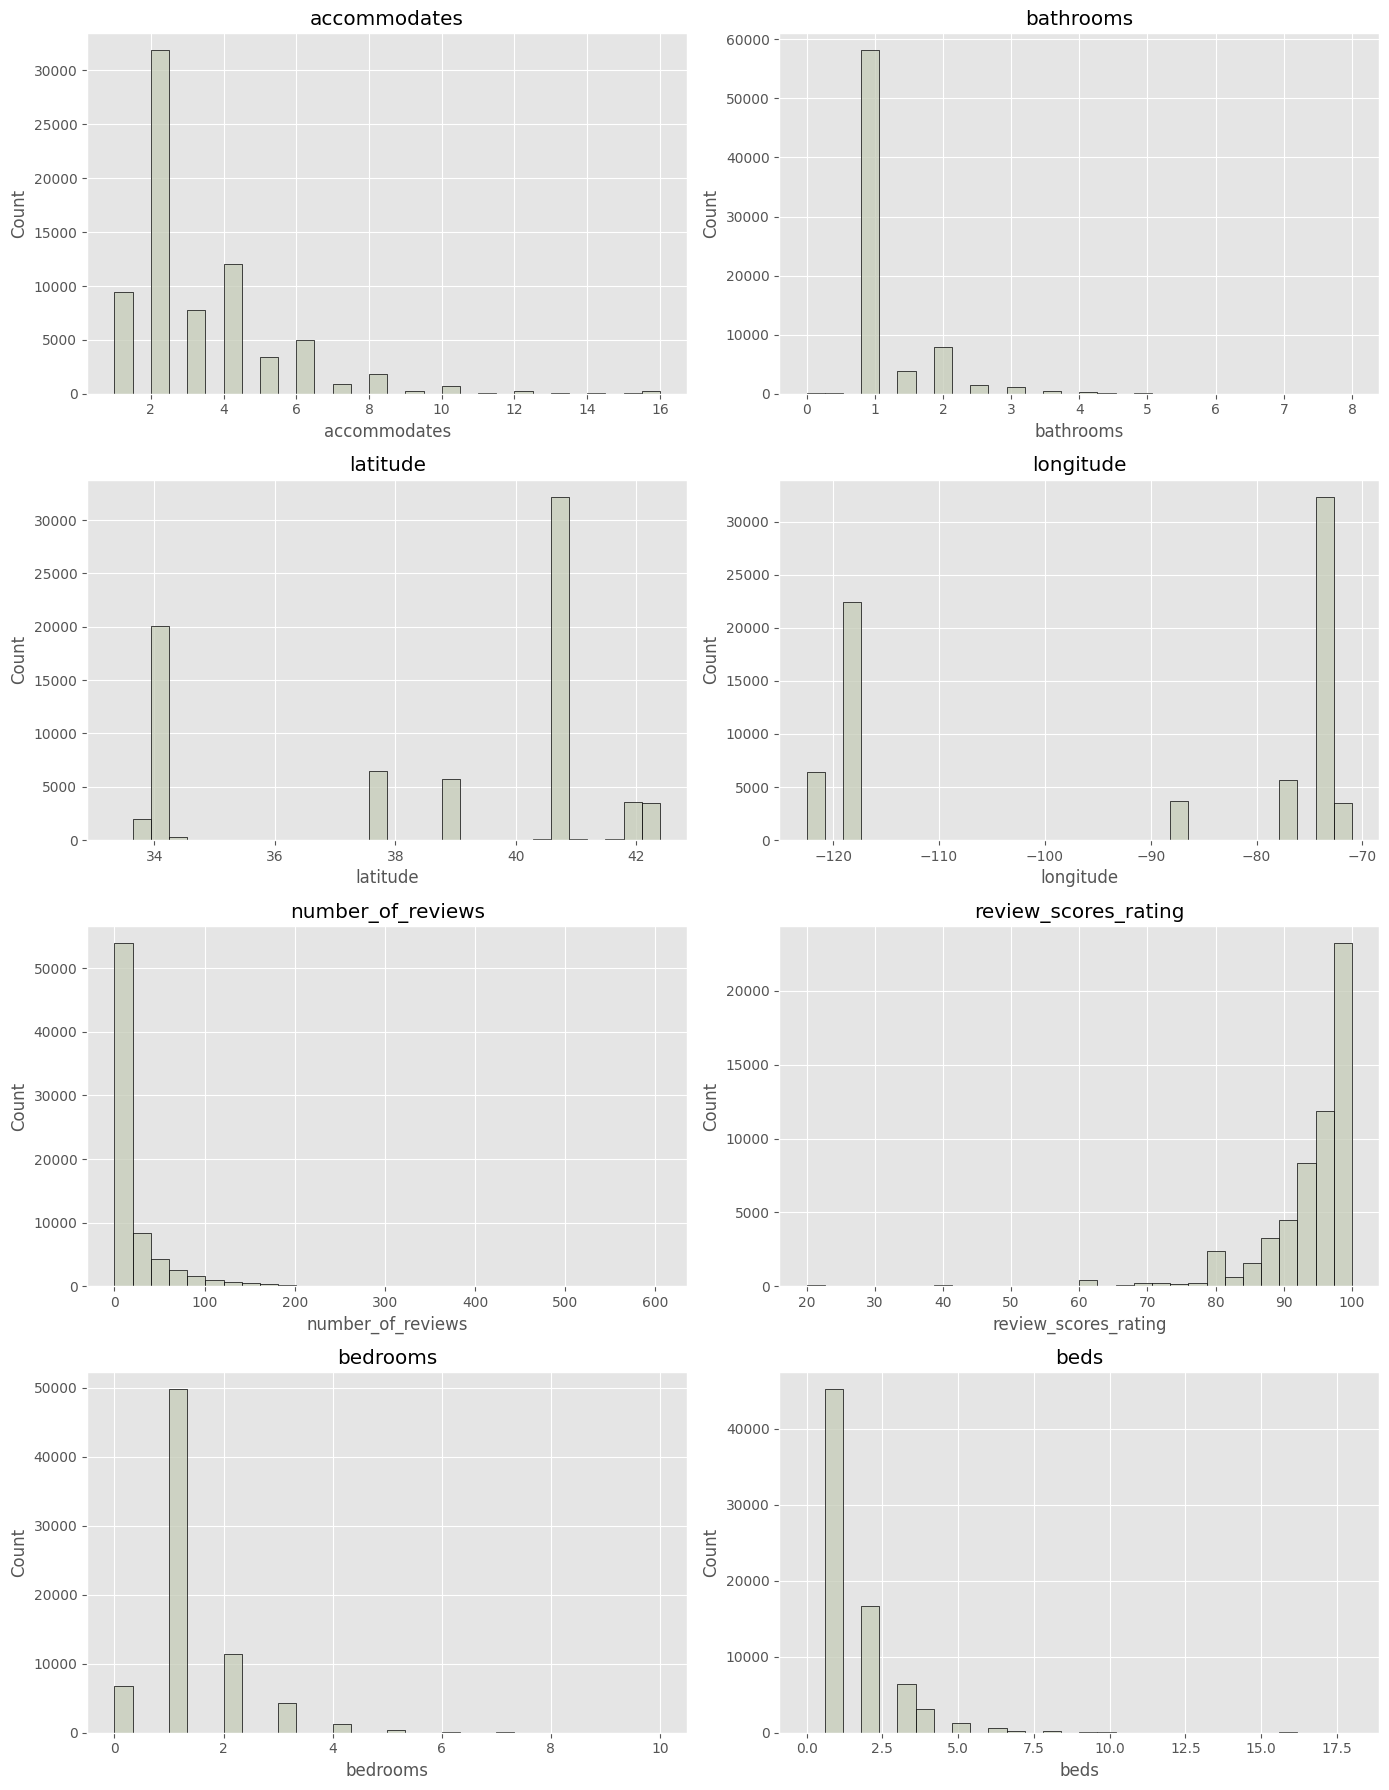

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.histplot(data=df, x=feature, bins=30, ax=axes[i], edgecolor="black", color="#c5ccb8")
    axes[i].set_title(feature)
    
plt.tight_layout()
plt.show()

Boxplots

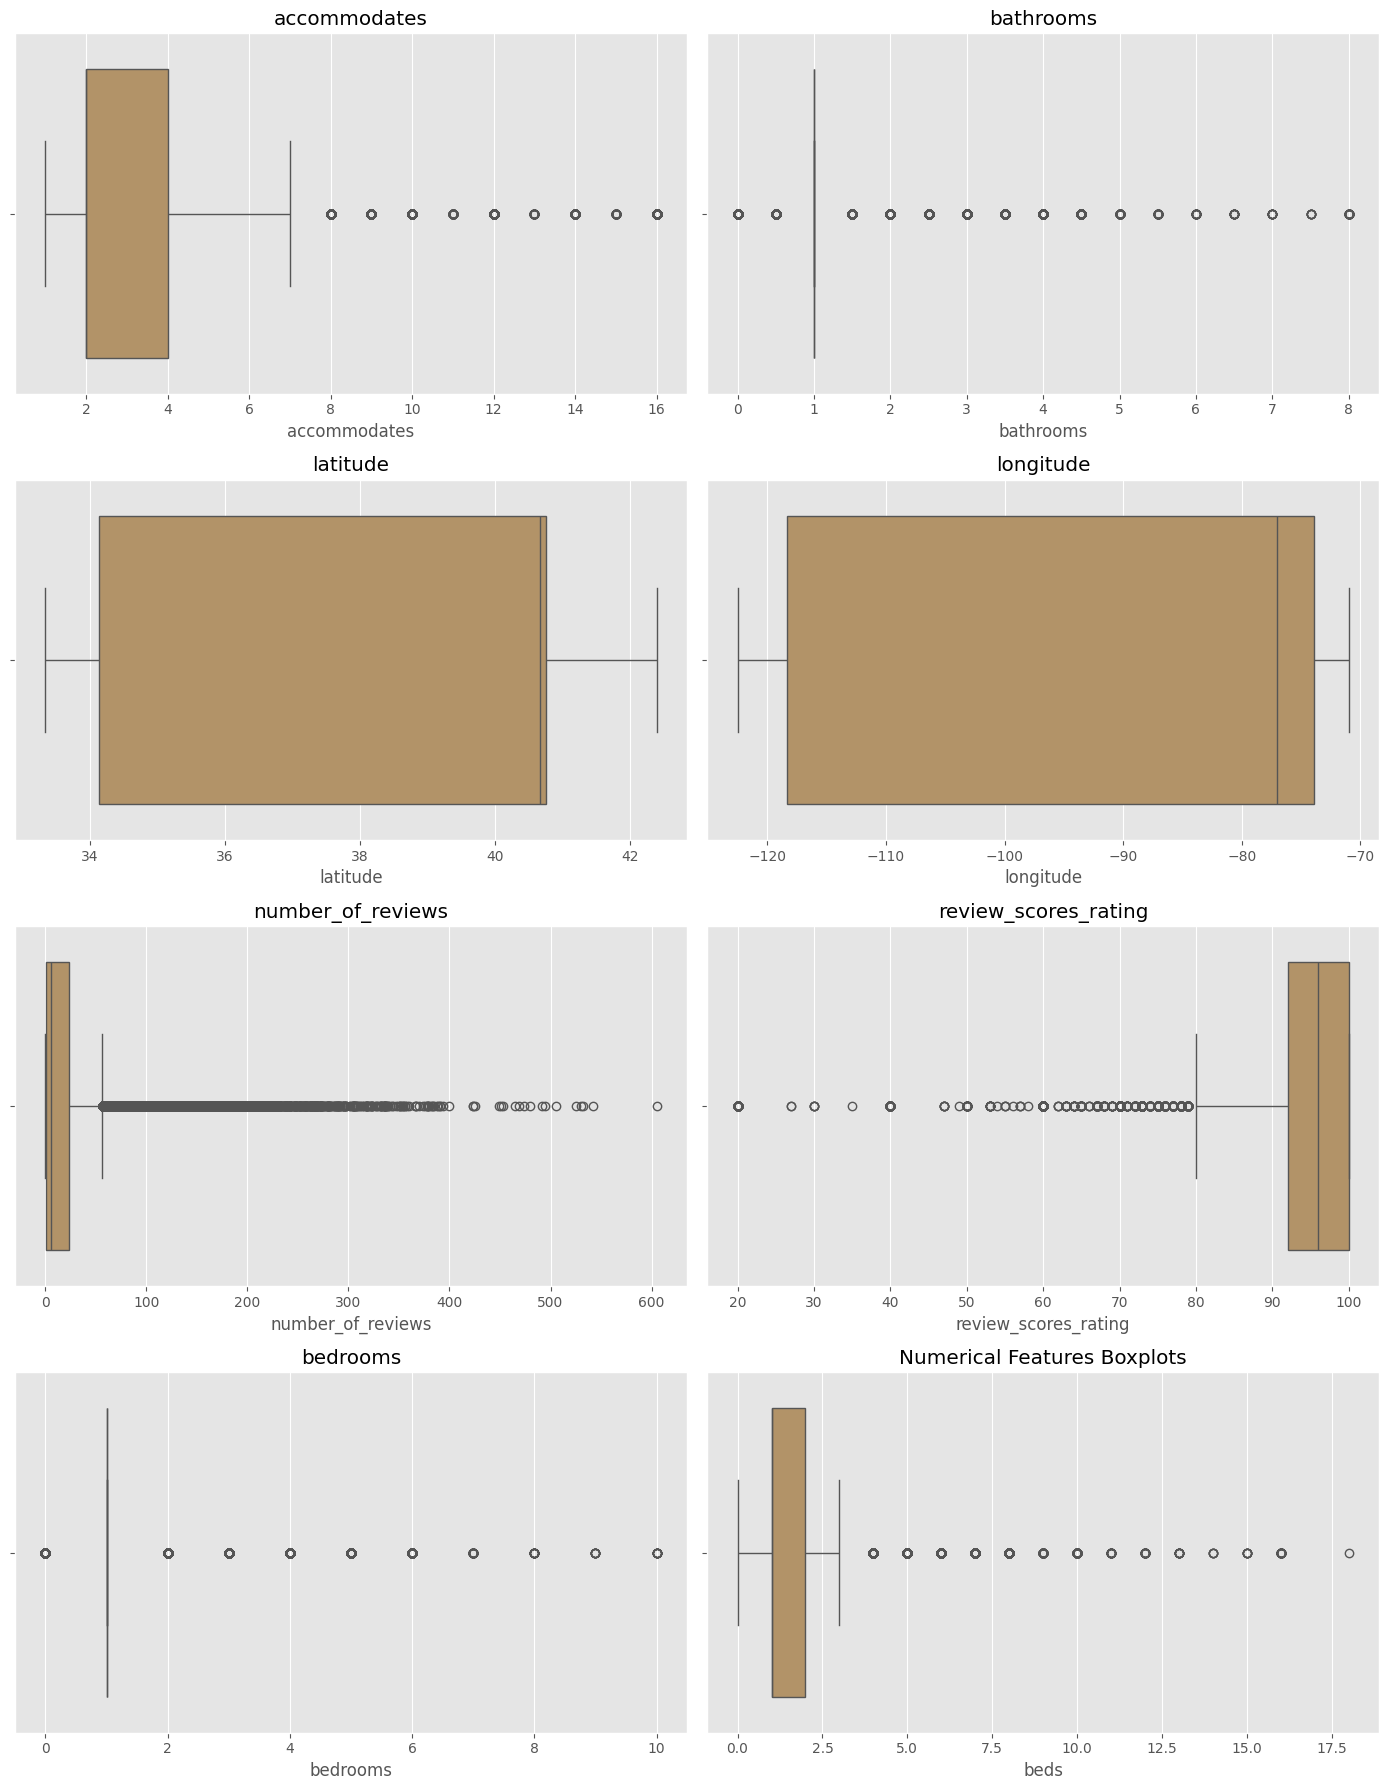

In [68]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 18))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.boxplot(x=df[feature], ax=axes[i], color="#be955c")
    axes[i].set_title(feature)

plt.title("Numerical Features Boxplots")
plt.tight_layout()
plt.show()

Skewness

In [69]:
df[numerical_features].skew().sort_values(ascending=False)

number_of_reviews       3.702835
bathrooms               3.691453
beds                    3.358000
accommodates            2.231561
bedrooms                1.989849
longitude              -0.407100
latitude               -0.534766
review_scores_rating   -3.380861
dtype: float64

# Categorical Feature Analysis

In [70]:
categorical_features = df.select_dtypes(include="object").columns.to_list()
categorical_features

['property_type',
 'room_type',
 'amenities',
 'bed_type',
 'cancellation_policy',
 'city',
 'description',
 'first_review',
 'host_has_profile_pic',
 'host_identity_verified',
 'host_response_rate',
 'host_since',
 'instant_bookable',
 'last_review',
 'name',
 'neighbourhood',
 'thumbnail_url',
 'zipcode']

Inspecting each one

In [71]:
for feature in categorical_features:
    print("=" * 60)
    print(feature)
    print(df[feature].value_counts().head())
    print()

property_type
property_type
Apartment      49003
House          16511
Condominium     2658
Townhouse       1692
Loft            1244
Name: count, dtype: int64

room_type
room_type
Entire home/apt    41310
Private room       30638
Shared room         2163
Name: count, dtype: int64

amenities
amenities
{}                                                                                                                                                                                                                                                                                                                        586
{"translation missing: en.hosting_amenity_49","translation missing: en.hosting_amenity_50"}                                                                                                                                                                                                                               135
{"Family/kid friendly"}                                       

Visualize the most important ones

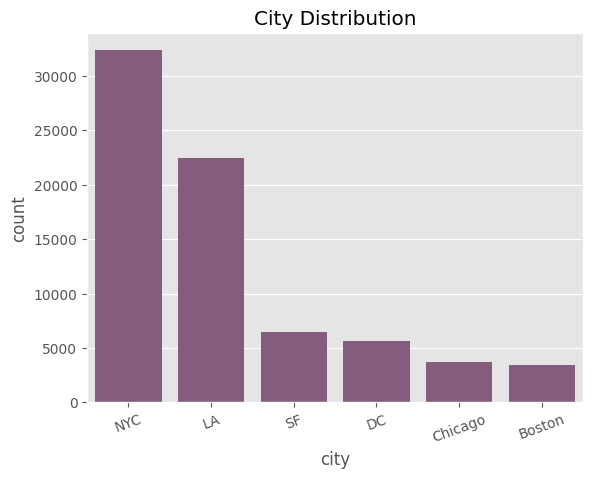

In [72]:
# city
sns.countplot(data=df, x="city", order=df["city"].value_counts().index, color="#8b5580")
plt.title("City Distribution")
plt.xticks(rotation=20)
plt.show()

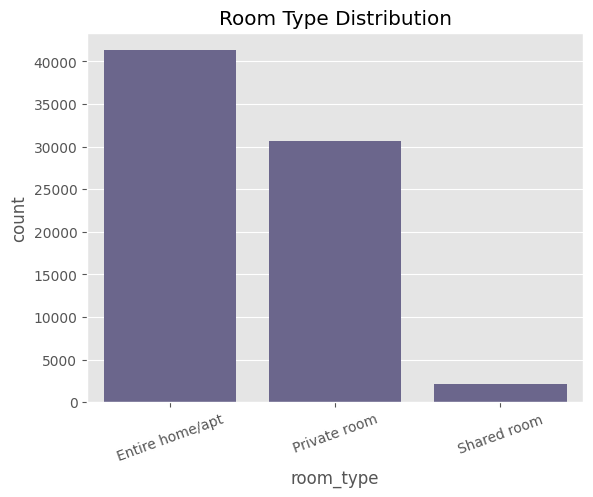

In [73]:
# room type
sns.countplot(data=df, x="room_type", order=df["room_type"].value_counts().index, color="#666092")
plt.title("Room Type Distribution")
plt.xticks(rotation=20)
plt.show()

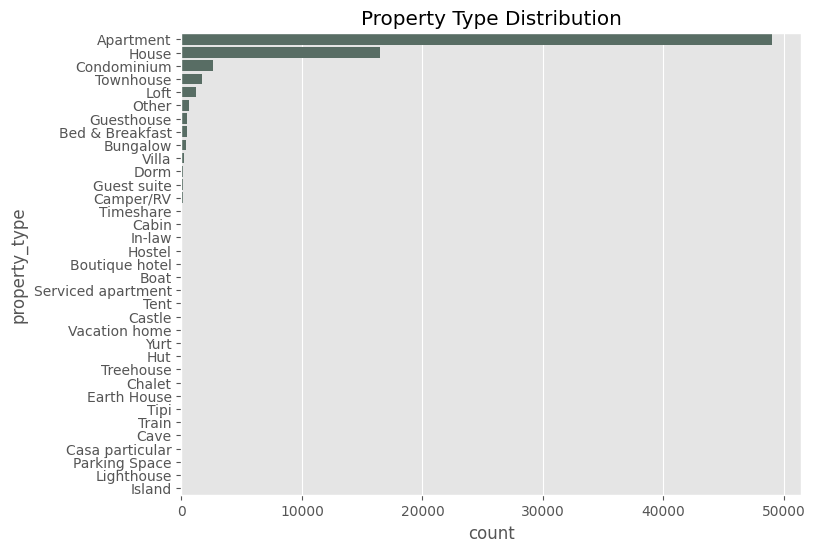

In [74]:
# property type
plt.figure(figsize=(8, 6))
sns.countplot(data=df, y="property_type", order=df["property_type"].value_counts().index, color="#557064", orient="h")
plt.title("Property Type Distribution")
plt.show()

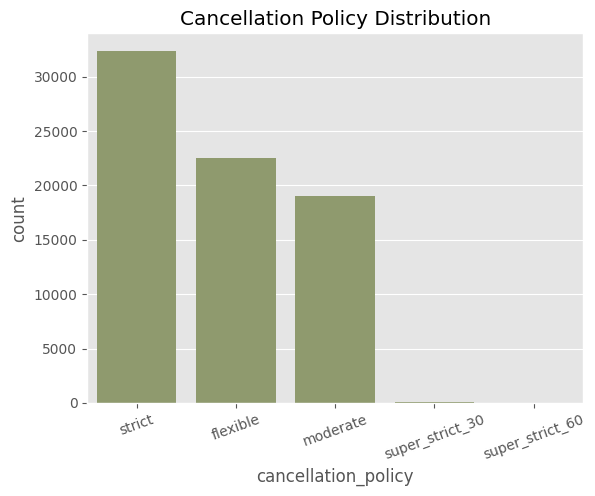

In [75]:
# cancellation policy
sns.countplot(data=df, x="cancellation_policy", order=df["cancellation_policy"].value_counts().index, color="#93a167")
plt.title("Cancellation Policy Distribution")
plt.xticks(rotation=20)
plt.show()

### Observations

Numerical features:

- Numerical features do not appear to contain impossible values. However, several variables contain extreme observations that should be investigated during preprocessing to determine whether they represent legitimate listings or data anomalies.

- `latitude` and `longitude` span multiple cities, suggesting that location is likely to be an important predictor of price.

- `number_of_reviews`, `bathrooms` and `beds` are highly skewed as implied by the skewness value above 3. This indicates presence of a few large values, which are also shown in the boxplots.

Categorical features:

- Categorical variables appear consistent and contain expected categories. However, some features (e.g., `property_type` and `neighbourhood`) exhibit high cardinality, which may require grouping or alternative encoding strategies.

- A large proportion of the dataset revolves around NYC and LA in terms of cities with most people booking an entire home/apartment (full privacy) or a private room (less privacy).

# 10. Relationship with the target (`log_price`)

Numerical Features vs. Target

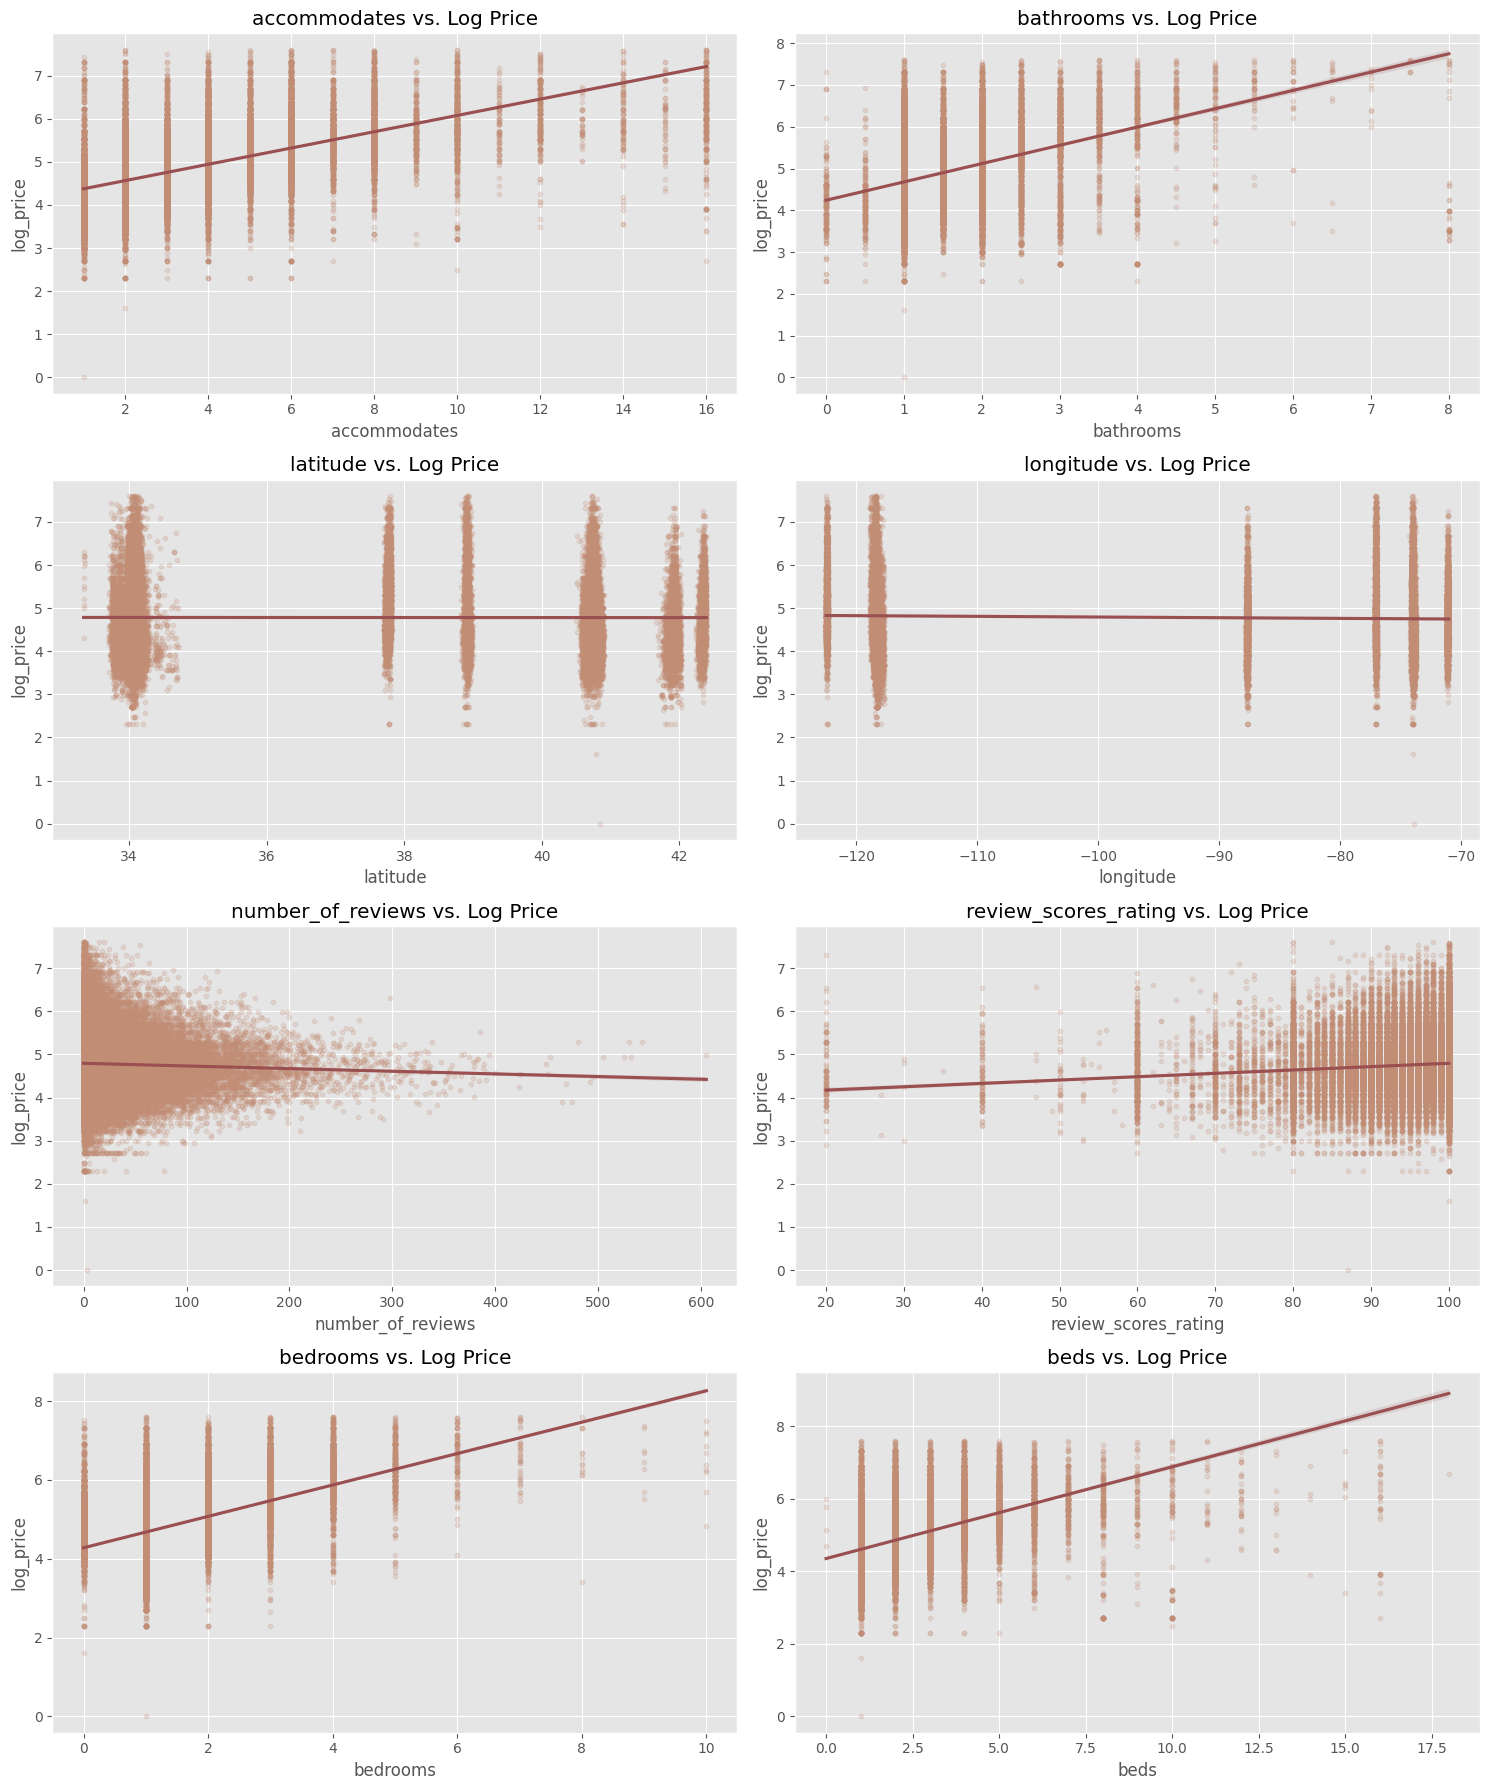

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(15, 18))
axes = axes.flatten()

for i, feature in enumerate(numerical_features):
    sns.regplot(data=df, x=feature, y="log_price", color="#c28d75", scatter_kws={"alpha": 0.2, "s": 10}, line_kws={"color": "#9a4f50"}, ax=axes[i])
    axes[i].set_title(f"{feature} vs. Log Price")

plt.tight_layout()
plt.show()

Categorical Features vs Target

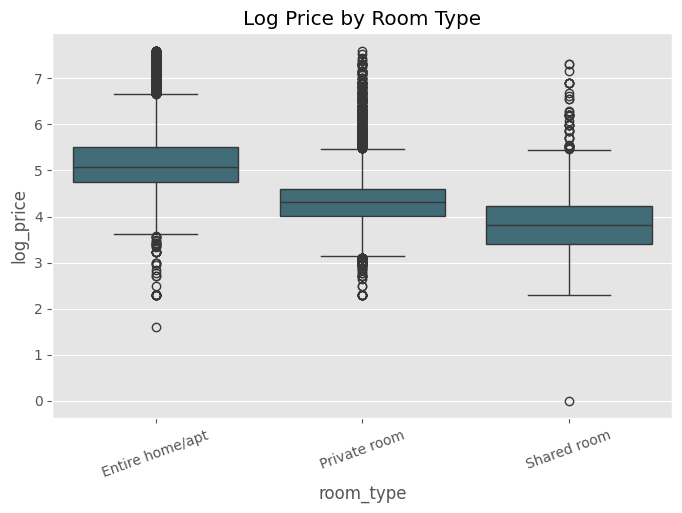

In [77]:
# room type
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="room_type", y="log_price", color="#387080")
plt.title("Log Price by Room Type")
plt.xticks(rotation=20)
plt.show()

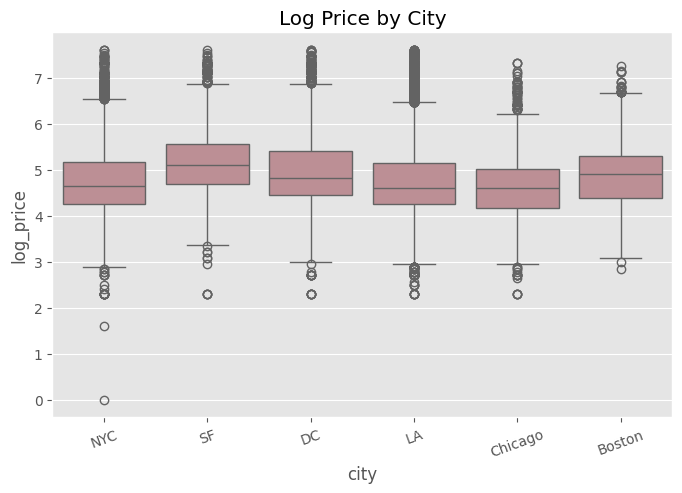

In [78]:
# city
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="city", y="log_price", color="#c38890")
plt.title("Log Price by City")
plt.xticks(rotation=20)
plt.show()

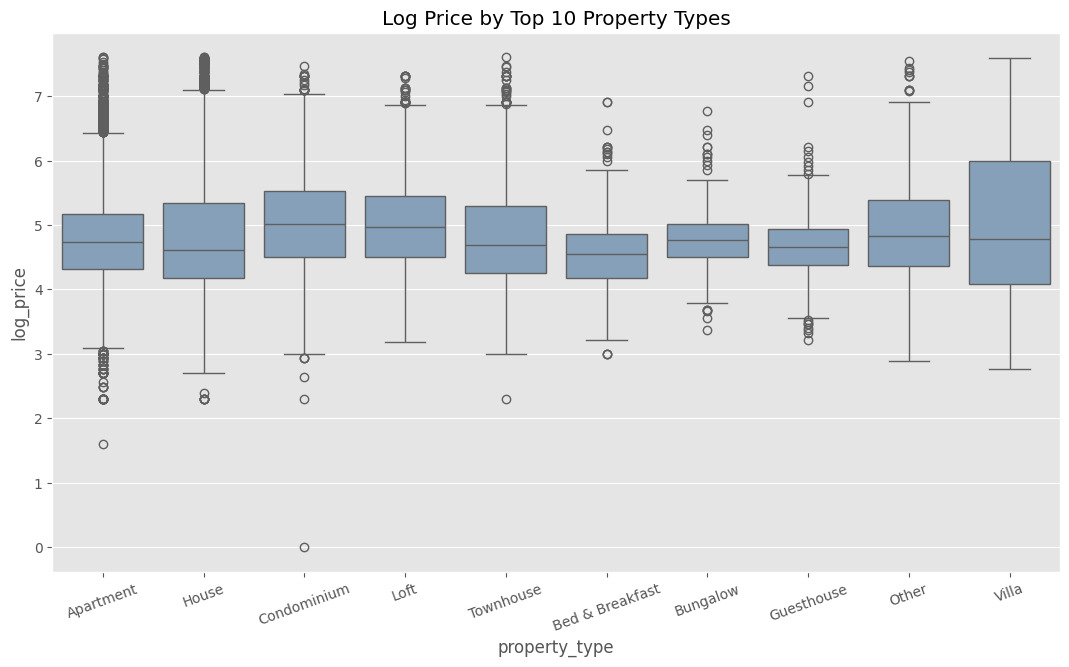

In [79]:
# property type (top 10 only since there are many)
most_common_properties = df["property_type"].value_counts().nlargest(10).index

plt.figure(figsize=(13, 7))
sns.boxplot(data=df[df["property_type"].isin(most_common_properties)], x="property_type", y="log_price", color="#7ca1c0")
plt.title("Log Price by Top 10 Property Types")
plt.xticks(rotation=20)
plt.show()

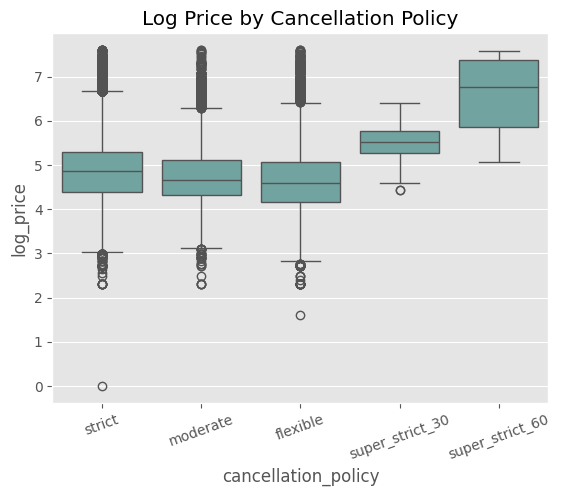

In [80]:
# cancellation policy
sns.boxplot(data=df, x="cancellation_policy", y="log_price", color="#68aca9")
plt.title("Log Price by Cancellation Policy")
plt.xticks(rotation=20)
plt.show()

Correlation Analysis

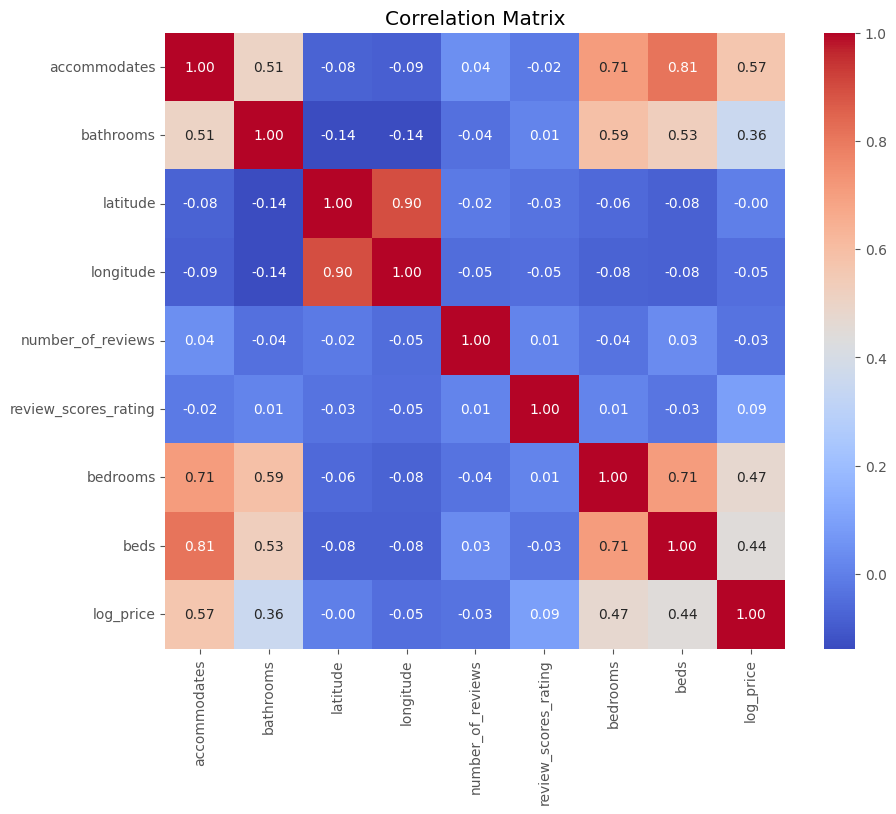

In [81]:
plt.figure(figsize=(10, 8))

corr = df[numerical_features + ["log_price"]].corr()

sns.heatmap(data=corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### Observations
Numerical Features vs Target
-	`accomodates`, `bathrooms`, `bedrooms` and `beds` show a positive linear relationship with `log_price`. This is also confirmed in the correlation analysis of numerical features.

Categorical Features vs Target
-	Median `log_price` for homes/apartment is higher compared to private rooms and shared rooms, though outliers are present.
-	Price distributions appear broadly similar across cities, though further statistical investigation may be required.
-	`log_price` values show no significant differences across the most common property types, though many outliers are present in the case of apartments, houses and townhouses.
-	`super_strict_30` or `super_strict_60` cancellation policy types exhibit higher median `log_price` compared to the other types. 

### Feature Engineering Ideas
-	`amenities` can be summarized as a single numerical feature by counting the different types of amenities in the property. Other useful features could be `HasWifi`, `HasKitchen` and `HasHeating`.
-	`thumbnail_url` doesn’t contain anything meaningful and will be dropped.
-	Date columns (such as year, month and day) can be deduced from `first_review`, `last_review` and `host_since`.
-	`description` can be used to create a description length column to see whether machine learning models can learn useful patterns from long/short descriptions. Additionally, a `word_count` feature may be a great further addition.
-	Since `host_response_rate` has many missing values, it may be used to create a binary column indicating whether a host has a recorded response rate.
-	Create occupancy-related ratios such as `accommodates_per_bedroom`, `beds_per_bedroom` and `bathrooms_per_bedroom`.
-	Group infrequent `property_type` categories into an ‘Other’ category.
-	Engineer location-based features using `latitude` and `longitude`.